<a href="https://colab.research.google.com/github/HakumenWorld/data-science-2026/blob/main/Pertemuan9_Febi_Kristiana_240401010231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aktivitas Hands-on: Prediksi Diagnosis
**Mata Kuliah:** Pengantar Data Science  
**Pertemuan:** 9  
**Nama:** Febi Kristiana  
**NIM:** 240401010231

Notebook ini disusun mengikuti bagian **Aktivitas Hands-on** pada modul pertemuan 9.  
Jalankan sel secara berurutan dari atas ke bawah di Google Colab.

## Langkah 0 — Buat File Jupyter Notebook Baru
Nama file sesuai modul: `Pertemuan9_[Nama]_[NIM].ipynb`

Aktivitas menggunakan **Breast Cancer Wisconsin** dari `scikit-learn` untuk membandingkan
**Logistic Regression** dan **Decision Tree**.

## Langkah 1 — Load & EDA Singkat

In [8]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant (ganas), 1 = benign (jinak)

print("Shape:", X.shape)
print("\nDistribusi target:")
print(pd.Series(y).map({0: "Malignant", 1: "Benign"}).value_counts())
print("\nProporsi target:")
print(pd.Series(y).value_counts(normalize=True).rename(index={0:"Malignant", 1:"Benign"}).round(3))

display(X.head())

Shape: (569, 30)

Distribusi target:
Benign       357
Malignant    212
Name: count, dtype: int64

Proporsi target:
Benign       0.627
Malignant    0.373
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
# Korelasi beberapa fitur utama sebagai EDA singkat
fitur_utama = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean smoothness", "mean concavity"
]
print("Korelasi antar fitur utama:")
display(X[fitur_utama].corr().round(2))

Korelasi antar fitur utama:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean concavity
mean radius,1.00,0.32,1.00,0.99,0.17,0.68
mean texture,0.32,1.00,0.33,0.32,-0.02,0.30
mean perimeter,1.00,0.33,1.00,0.99,0.21,0.72
mean area,0.99,0.32,0.99,1.00,0.18,0.69
mean smoothness,0.17,-0.02,0.21,0.18,1.00,0.52
mean concavity,0.68,0.30,0.72,0.69,0.52,1.00


## Langkah 2 — Preprocessing

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Data latih:", X_train.shape)
print("Data uji  :", X_test.shape)

Data latih: (455, 30)
Data uji  : (114, 30)


## Langkah 3 — Latih Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": log_model.coef_[0]
}).sort_values("Koefisien", key=abs, ascending=False)

print("5 fitur dengan |koefisien| terbesar:")
display(coef_df.head())

5 fitur dengan |koefisien| terbesar:


,Fitur,Koefisien
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616


**Interpretasi singkat:** semakin besar nilai absolut koefisien, semakin kuat pengaruh fitur
terhadap keputusan model. Tanda positif mengarah ke kelas `1 = Benign`, sedangkan tanda negatif
mengarah ke kelas `0 = Malignant`.

## Langkah 4 — Latih Decision Tree

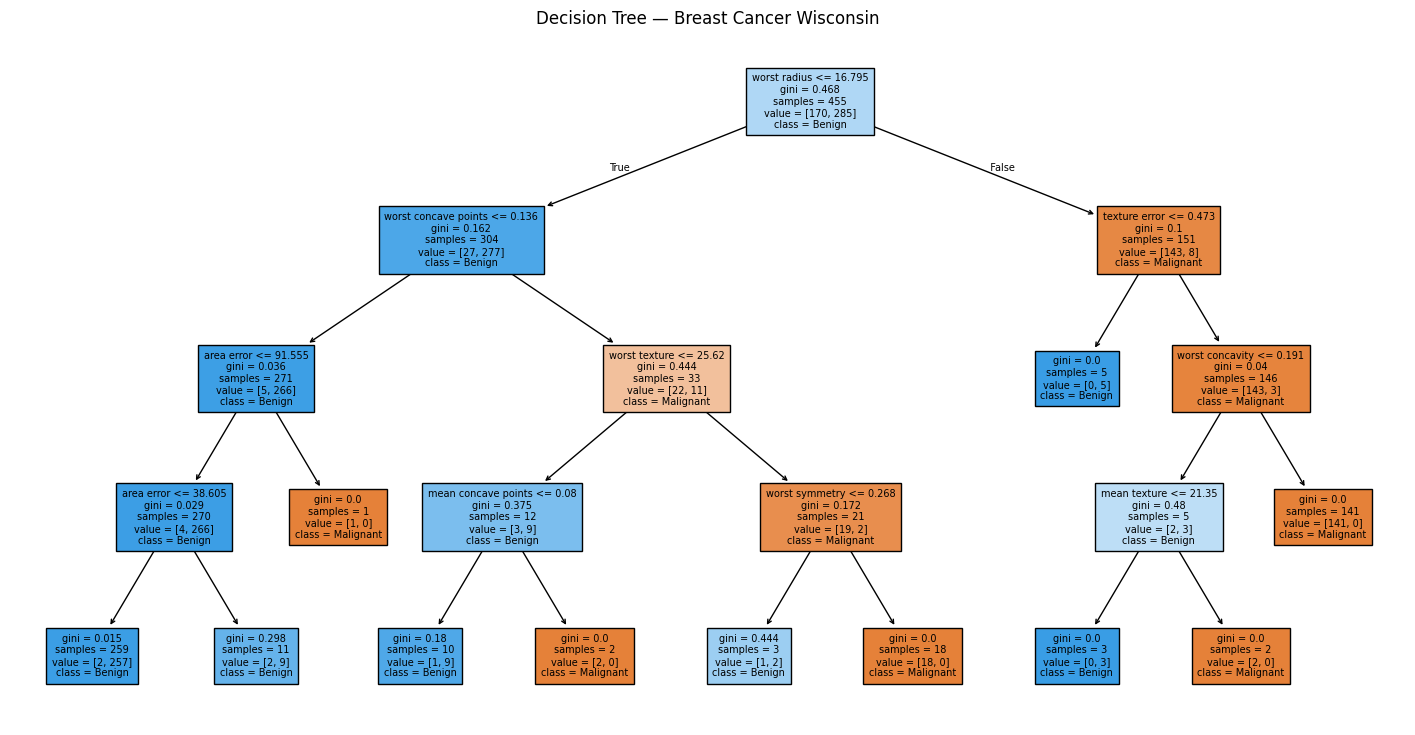

In [12]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(18, 9))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True,
    fontsize=7
)
plt.title("Decision Tree — Breast Cancer Wisconsin")
plt.show()

## Langkah 5 — Evaluasi & Bandingkan

In [13]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

hasil = []

for name, y_pred in [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_tree)
]:
    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision (Benign/kelas 1): {precision_score(y_test, y_pred):.3f}")
    print(f"Recall    (Benign/kelas 1): {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score  (Benign/kelas 1): {f1_score(y_test, y_pred):.3f}")

    # Tambahan teknis: karena Malignant diberi label 0, recall kanker dihitung dengan pos_label=0.
    recall_malignant = recall_score(y_test, y_pred, pos_label=0)
    print(f"Recall Malignant (kelas 0): {recall_malignant:.3f}")

    hasil.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_Benign": precision_score(y_test, y_pred),
        "Recall_Benign": recall_score(y_test, y_pred),
        "F1_Benign": f1_score(y_test, y_pred),
        "Recall_Malignant": recall_malignant
    })

hasil_df = pd.DataFrame(hasil).set_index("Model")
print("\nRingkasan perbandingan:")
display(hasil_df.round(3))


=== Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision (Benign/kelas 1): 0.986
Recall    (Benign/kelas 1): 0.986
F1-Score  (Benign/kelas 1): 0.986
Recall Malignant (kelas 0): 0.976

=== Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision (Benign/kelas 1): 0.958
Recall    (Benign/kelas 1): 0.944
F1-Score  (Benign/kelas 1): 0.951
Recall Malignant (kelas 0): 0.929

Ringkasan perbandingan:


,Accuracy,Precision_Benign,Recall_Benign,F1_Benign,Recall_Malignant
Model,,,,,
Logistic Regression,0.982,0.986,0.986,0.986,0.976
Decision Tree,0.939,0.958,0.944,0.951,0.929


### Analisis
Modul menekankan **Recall** karena *False Negative* pada diagnosis kanker berarti kasus kanker
dapat terlewat. Perlu diperhatikan bahwa dataset memberi label `0 = Malignant` dan `1 = Benign`,
sehingga `recall_score()` default dari scikit-learn sebenarnya menghitung recall kelas Benign.
Untuk menilai kemampuan mendeteksi kanker, gunakan kolom **Recall_Malignant** pada tabel di atas.

Setelah menjalankan notebook, bandingkan:
1. Model mana yang memiliki `Recall_Malignant` lebih tinggi?
2. Mengapa recall lebih kritis daripada accuracy pada kasus diagnosis?
3. Apakah selisih performa kedua model cukup besar untuk dianggap penting secara praktis?

Berikut adalah jawaban untuk pertanyaan Anda:

1.  **Model mana yang memiliki `Recall_Malignant` lebih tinggi?**
    Berdasarkan ringkasan perbandingan (`hasil_df`) dan sel keluaran sebelumnya, **Logistic Regression** memiliki `Recall_Malignant` yang lebih tinggi (0.976) dibandingkan dengan Decision Tree (0.929).

2.  **Mengapa recall lebih kritis daripada accuracy pada kasus diagnosis?**
    Recall lebih kritis pada kasus diagnosis, terutama untuk penyakit serius seperti kanker, karena kita ingin meminimalkan *False Negatives*. *False Negative* berarti seseorang yang sebenarnya menderita kanker salah didiagnosis tidak memiliki kanker. Ini adalah kesalahan yang jauh lebih berbahaya daripada *False Positive* (seseorang yang tidak menderita kanker salah didiagnosis memiliki kanker), karena *False Negative* dapat menunda pengobatan dan memperburuk prognosis pasien. Accuracy dapat menjadi tinggi meskipun model memiliki banyak *False Negatives* jika kelas negatif mendominasi, sehingga recall lebih relevan untuk memastikan sensitivitas model dalam mendeteksi kasus positif yang sebenarnya.

3.  **Apakah selisih performa kedua model cukup besar untuk dianggap penting secara praktis?**
    Ya, selisih performa kedua model cukup besar dan penting secara praktis. Perbedaan `Recall_Malignant` sebesar 0.047 (0.976 - 0.929) berarti Logistic Regression mampu mengidentifikasi hampir 5% lebih banyak kasus kanker yang sebenarnya dibandingkan Decision Tree pada data uji. Dalam konteks diagnosis medis, setiap persentase peningkatan dalam deteksi dini dapat memiliki dampak signifikan pada hasil pasien.

In [14]:
model_terbaik = hasil_df["Recall_Malignant"].idxmax()
nilai_recall = hasil_df.loc[model_terbaik, "Recall_Malignant"]

print(
    f"Berdasarkan Recall Malignant, model yang lebih baik adalah {model_terbaik} "
    f"dengan recall {nilai_recall:.3f}. "
    "Recall penting pada diagnosis karena kita ingin meminimalkan pasien kanker "
    "yang salah diprediksi sebagai bukan kanker (false negative)."
)

Berdasarkan Recall Malignant, model yang lebih baik adalah Logistic Regression dengan recall 0.976. Recall penting pada diagnosis karena kita ingin meminimalkan pasien kanker yang salah diprediksi sebagai bukan kanker (false negative).


## Kesimpulan Notebook

Notebook ini telah menyajikan alur kerja lengkap dalam membangun dan mengevaluasi model klasifikasi untuk diagnosis kanker payudara menggunakan dataset Breast Cancer Wisconsin. Berikut adalah poin-poin penting dari analisis:

1.  **Eksplorasi Data Awal (EDA):** Data berhasil dimuat dan sekilas EDA menunjukkan distribusi target yang tidak seimbang (lebih banyak kasus benign) dan korelasi antar fitur yang relevan, terutama di antara fitur-fitur utama.

2.  **Pra-pemrosesan Data:** Data dibagi menjadi set pelatihan dan pengujian, dengan stratifikasi untuk mempertahankan proporsi kelas. Fitur-fitur diskalakan menggunakan `StandardScaler` untuk memastikan model berbasis jarak (seperti Logistic Regression) tidak bias terhadap fitur dengan skala yang lebih besar.

3.  **Pelatihan Model:** Dua model klasifikasi, Logistic Regression dan Decision Tree, dilatih. Logistic Regression dilatih pada data yang diskalakan, dan Decision Tree dilatih dengan `max_depth` 4 untuk menjaga interpretasi. Koefisien Logistic Regression memberikan wawasan tentang pentingnya fitur, sementara visualisasi Decision Tree menawarkan interpretasi berbasis aturan.

4.  **Evaluasi dan Perbandingan Model:** Kedua model dievaluasi menggunakan berbagai metrik, dengan penekanan khusus pada **Recall Malignant**. Hasil menunjukkan:
    *   **Logistic Regression** mencapai `Recall_Malignant` yang lebih tinggi (0.976) dan akurasi keseluruhan yang lebih baik (0.982).
    *   **Decision Tree** memiliki `Recall_Malignant` 0.929 dan akurasi 0.939.

5.  **Implikasi Klinis:** Analisis menegaskan bahwa `Recall_Malignant` adalah metrik paling kritis dalam kasus diagnosis kanker untuk meminimalkan *False Negatives*. Perbedaan performa antara kedua model, meskipun terlihat kecil secara numerik, memiliki implikasi praktis yang signifikan dalam konteks medis, di mana deteksi dini sangat penting.

**Kesimpulan Akhir:** Berdasarkan hasil evaluasi, **Logistic Regression** adalah model yang lebih unggul untuk tugas diagnosis ini karena kemampuannya yang lebih baik dalam mengidentifikasi kasus kanker (`Recall_Malignant` lebih tinggi). Pentingnya meminimalkan *False Negatives* dalam diagnosis medis menggarisbawahi pilihan metrik recall sebagai kunci keberhasilan model.

## Langkah 6 — Upload ke GitHub
Setelah seluruh sel berhasil dijalankan dan output terlihat, simpan notebook ke GitHub
lalu submit tautannya ke Forum Diskusi 9 di LMS.